In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/data_final_version.csv')

создание папки отчётов, стилизация

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports', exist_ok=True)

# Единый стиль для всех графиков диплома
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 100


Распределение целевой переменной (Price)

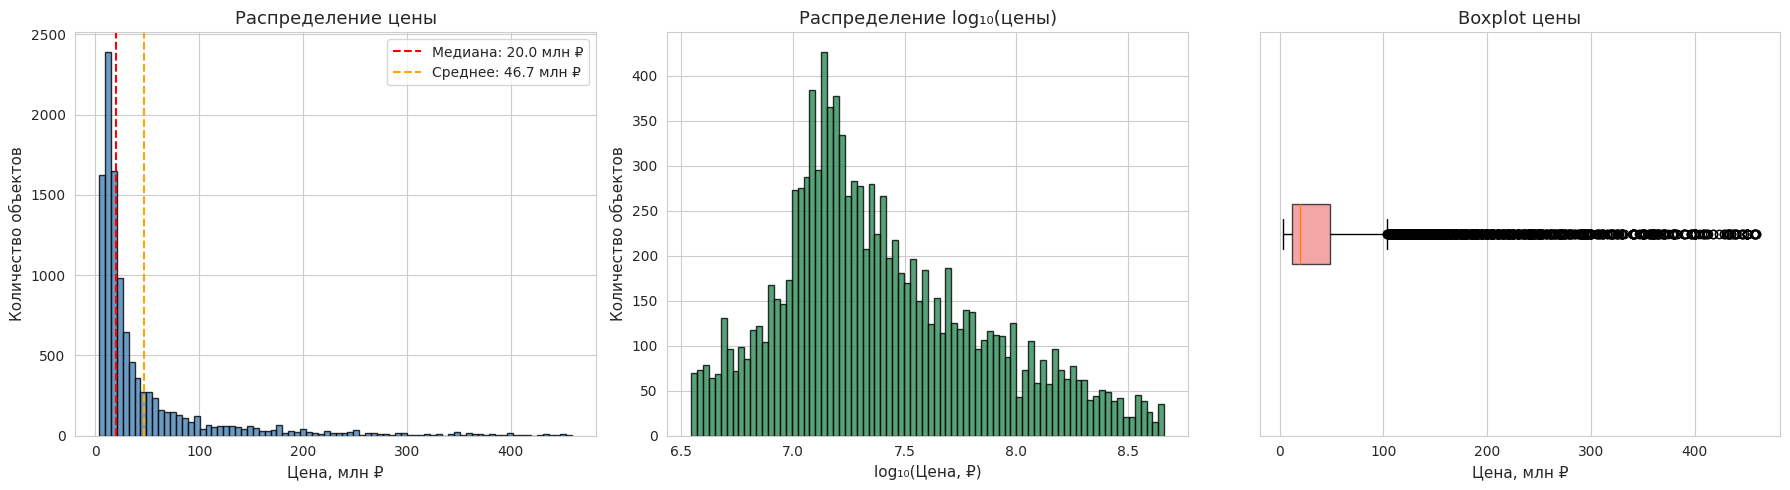

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1.1 Гистограмма цены в исходном масштабе
axes[0].hist(df['Price'] / 1e6, bins=80, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение цены')
axes[0].set_xlabel('Цена, млн ₽')
axes[0].set_ylabel('Количество объектов')
axes[0].axvline(df['Price'].median() / 1e6, color='red', linestyle='--',
                label=f'Медиана: {df["Price"].median()/1e6:.1f} млн ₽')
axes[0].axvline(df['Price'].mean() / 1e6, color='orange', linestyle='--',
                label=f'Среднее: {df["Price"].mean()/1e6:.1f} млн ₽')
axes[0].legend()

# 1.2 Гистограмма логарифма цены
log_price = np.log10(df['Price'])
axes[1].hist(log_price, bins=80, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение log₁₀(цены)')
axes[1].set_xlabel('log₁₀(Цена, ₽)')
axes[1].set_ylabel('Количество объектов')

# 1.3 Boxplot цены
axes[2].boxplot(df['Price'] / 1e6, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7))
axes[2].set_title('Boxplot цены')
axes[2].set_xlabel('Цена, млн ₽')
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('reports/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Распределения числовых признаков

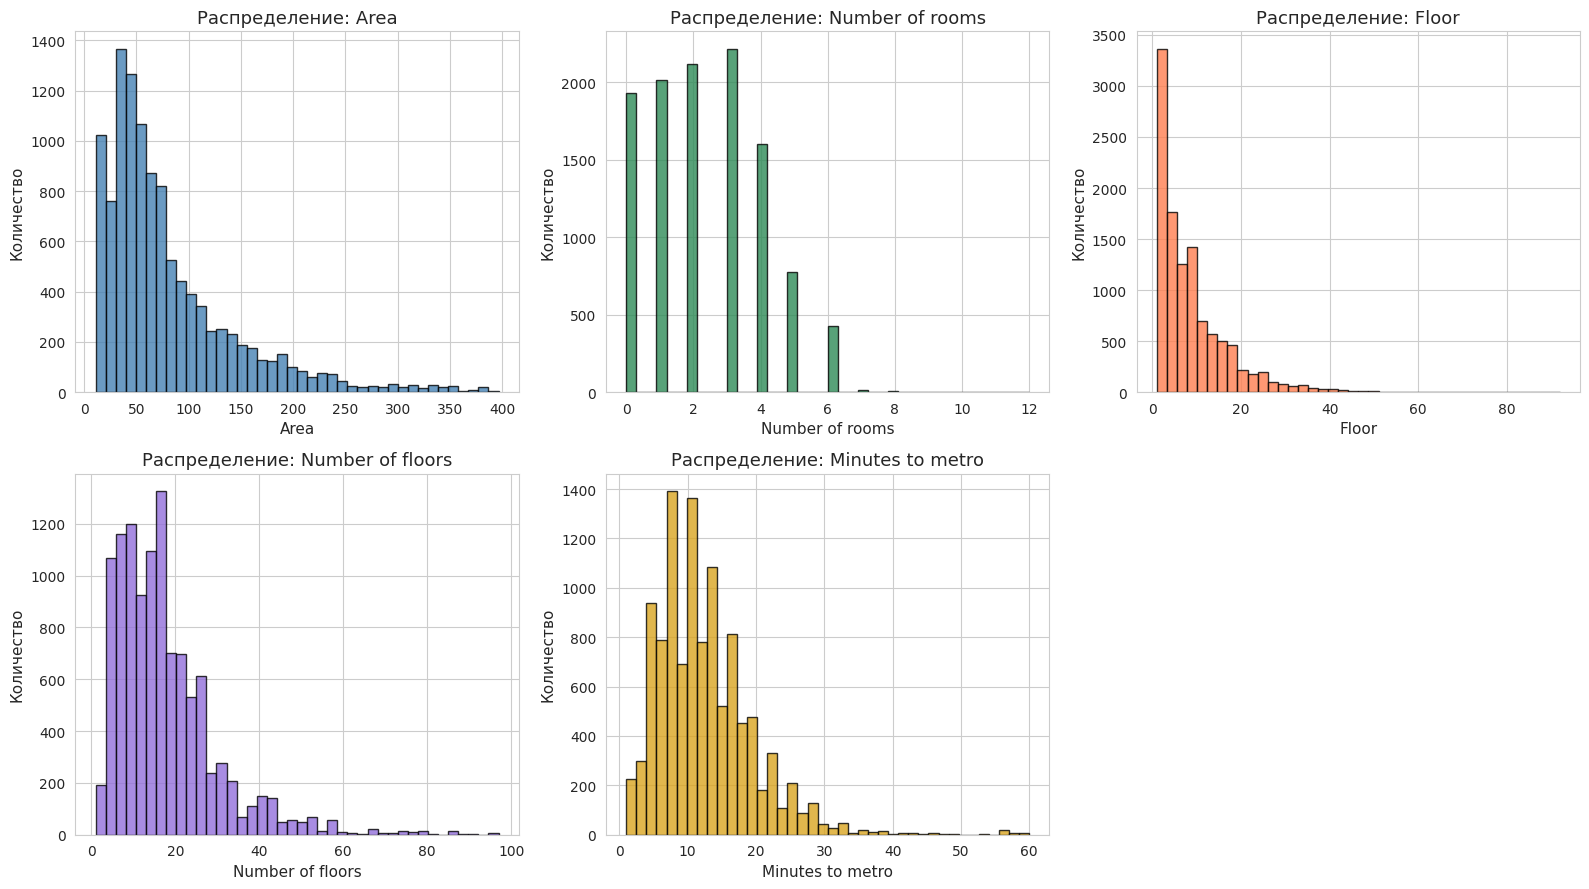

In [11]:
numeric_cols = ['Area', 'Number of rooms', 'Floor', 'Number of floors', 'Minutes to metro']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'goldenrod']
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')

# Прячем последний пустой subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('reports/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Корреляционная матрица

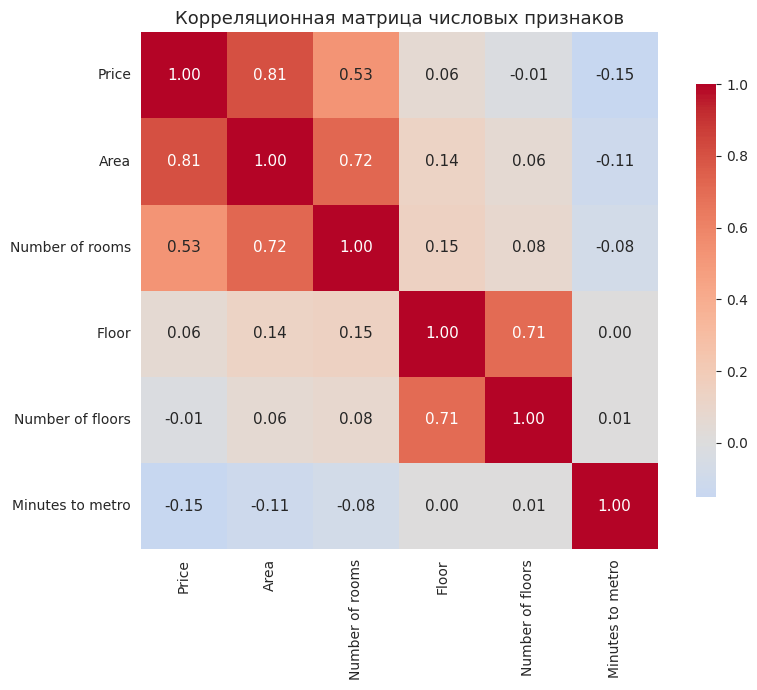

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

corr_cols = ['Price', 'Area', 'Number of rooms', 'Floor', 'Number of floors', 'Minutes to metro']
corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Корреляционная матрица числовых признаков', fontsize=13)
plt.tight_layout()
plt.savefig('reports/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Scatter-графики - ключевые зависимости

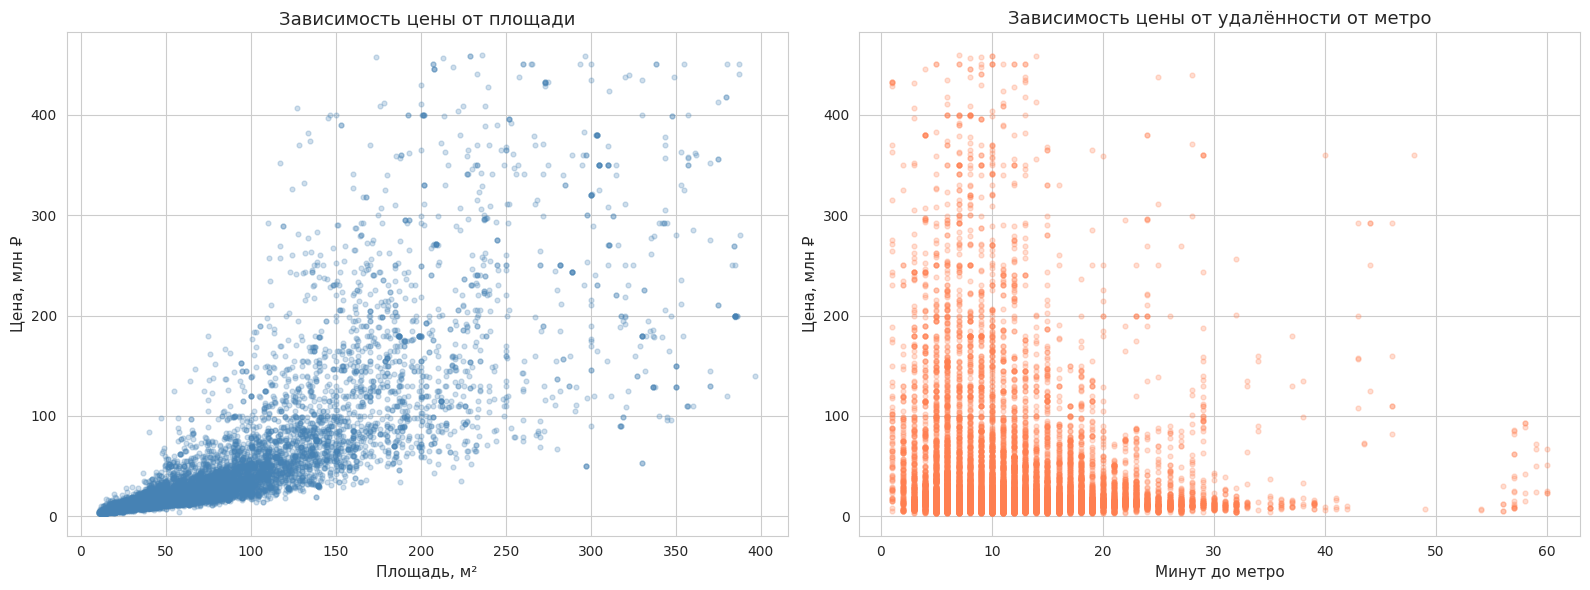

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Площадь vs Цена
axes[0].scatter(df['Area'], df['Price'] / 1e6, alpha=0.25, s=12, color='steelblue')
axes[0].set_title('Зависимость цены от площади')
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, млн ₽')

# Расстояние до метро vs Цена
axes[1].scatter(df['Minutes to metro'], df['Price'] / 1e6, alpha=0.25, s=12, color='coral')
axes[1].set_title('Зависимость цены от удалённости от метро')
axes[1].set_xlabel('Минут до метро')
axes[1].set_ylabel('Цена, млн ₽')

plt.tight_layout()
plt.savefig('reports/04_scatter_price.png', dpi=150, bbox_inches='tight')
plt.show()


Категориальные признаки

C:\Users\roman\AppData\Local\Temp\ipykernel_37488\4055996869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Renovation', y=df['Price'] / 1e6, order=renovation_order,


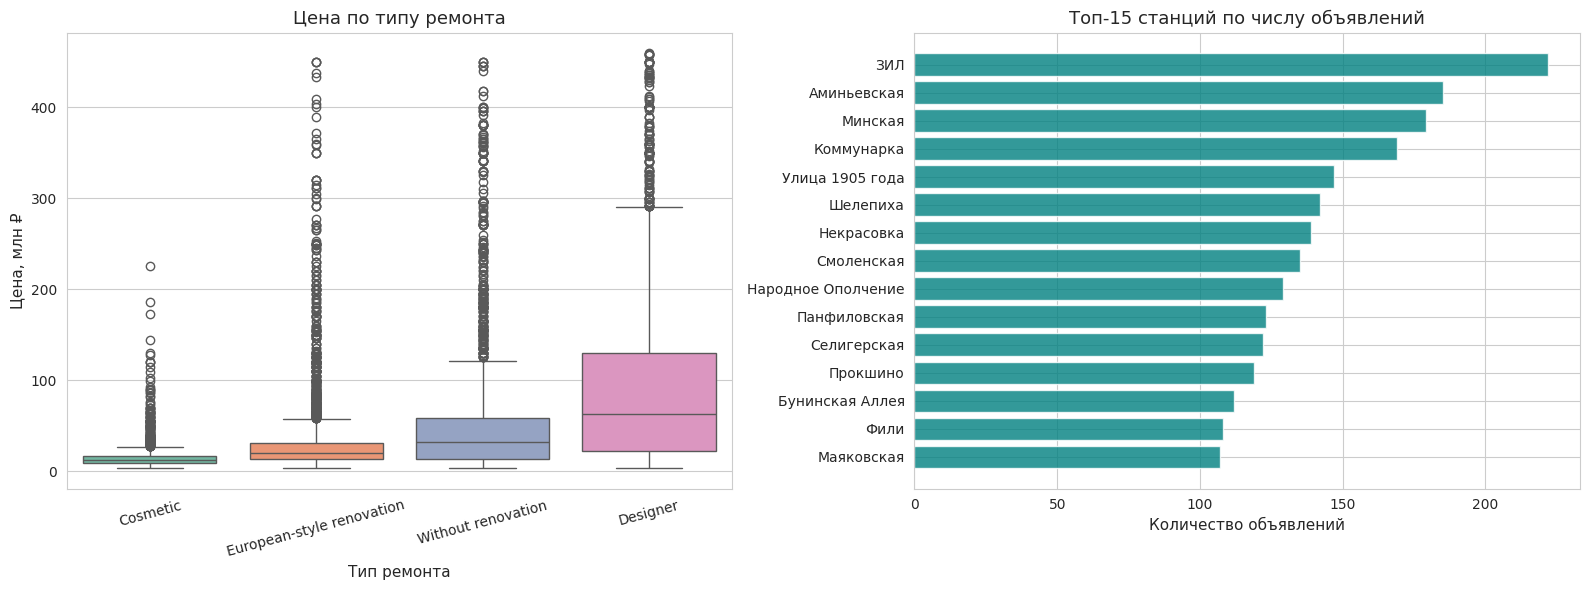

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot цены по типам ремонта
renovation_order = df.groupby('Renovation')['Price'].median().sort_values().index.tolist()
sns.boxplot(data=df, x='Renovation', y=df['Price'] / 1e6, order=renovation_order,
            ax=axes[0], palette='Set2')
axes[0].set_title('Цена по типу ремонта')
axes[0].set_ylabel('Цена, млн ₽')
axes[0].set_xlabel('Тип ремонта')
axes[0].tick_params(axis='x', rotation=15)

# Топ-15 станций по числу объявлений
top_stations = df['Metro station'].value_counts().head(15)
axes[1].barh(top_stations.index[::-1], top_stations.values[::-1], color='teal', alpha=0.8)
axes[1].set_title('Топ-15 станций по числу объявлений')
axes[1].set_xlabel('Количество объявлений')

plt.tight_layout()
plt.savefig('reports/05_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
